<a href="https://colab.research.google.com/github/Sammystar434/medical-diagnosis-network/blob/model-tuning/Model_Improvement_and_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [232]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from google.colab import files

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

## 1. Load the processed data

In [233]:
# 1. LOAD THE PROCESSED DATA
# (the three split files from the preprocessing notebook)

base_url = "https://raw.githubusercontent.com/Group-22-AI-ML/medical-diagnosis-network/main/Model/Preprocessing/"

train = pd.read_csv(base_url + "train.csv")
val = pd.read_csv(base_url + "validation.csv")
test = pd.read_csv(base_url + "test.csv")

X_train = train.drop("class", axis=1)
y_train = train["class"].values

X_val = val.drop("class", axis=1)
y_val = val["class"].values

X_test = test.drop("class", axis=1)
y_test = test["class"].values

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Xtr, Xva, Xte = (d.values.astype("float32") for d in (X_train, X_val, X_test))

Train: (364, 10)
Validation: (78, 10)
Test: (78, 10)


## 2. Architecture

In [234]:
# ARCHITECTURE
model = keras.Sequential([
    layers.Input(shape=(Xtr.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="baseline_mlp")

## 3. Training settings and training

In [235]:
# TRAINING SETTINGS
LOSS, LR, BATCH_SIZE, MAX_EPOCHS, PATIENCE = "binary_crossentropy", 0.001, 32, 300, 15
model.compile(loss=LOSS, optimizer=keras.optimizers.Adam(learning_rate=LR), metrics=["accuracy"])
model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
history = model.fit(Xtr, y_train, validation_data=(Xva, y_val),
                    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=0)
epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nStopped after {epochs_run} epochs; best epoch = {best_epoch}")

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_261 (Dense)               │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_262 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_263 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)


Stopped after 43 epochs; best epoch = 28


## 4. Evaluation (test set)


Accuracy : 0.9103
Precision: 0.8776
Recall   : 0.9773
F1-score : 0.9247

                  precision    recall  f1-score   support

No diabetes (0)       0.97      0.82      0.89        34
   Diabetes (1)       0.88      0.98      0.92        44

       accuracy                           0.91        78
      macro avg       0.92      0.90      0.91        78
   weighted avg       0.92      0.91      0.91        78



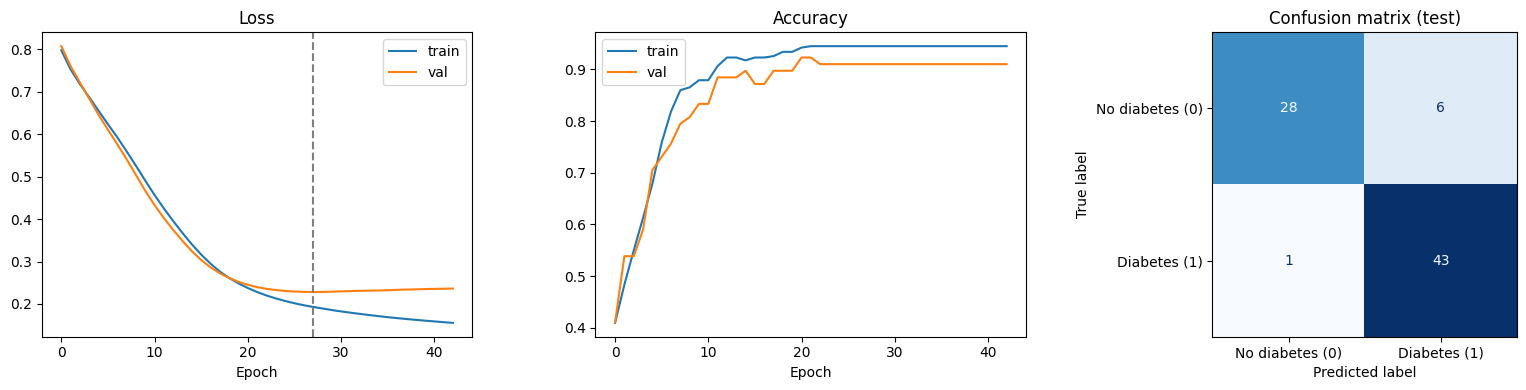

In [236]:
# EVALUATION (test set, threshold 0.5)

pred = (model.predict(Xte, verbose=0).ravel() >= 0.5).astype(int)
acc  = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, zero_division=0)
rec  = recall_score(y_test, pred, zero_division=0)
f1   = f1_score(y_test, pred, zero_division=0)
cm   = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nAccuracy : {acc:.4f}\nPrecision: {prec:.4f}\nRecall   : {rec:.4f}\nF1-score : {f1:.4f}")
print("\n", classification_report(y_test, pred, target_names=["No diabetes (0)", "Diabetes (1)"], zero_division=0))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(history.history["loss"], label="train"); ax[0].plot(history.history["val_loss"], label="val")
ax[0].axvline(best_epoch - 1, ls="--", c="gray"); ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train"); ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
ConfusionMatrixDisplay(cm, display_labels=["No diabetes (0)", "Diabetes (1)"]).plot(
    ax=ax[2], cmap="Blues", values_format="d", colorbar=False)
ax[2].set_title("Confusion matrix (test)")
plt.tight_layout(); plt.savefig("baseline_plots.png", dpi=150); plt.show()

In [237]:
# 5. SUMMARY

summary = f"""BASELINE NEURAL NETWORK - SUMMARY

ARCHITECTURE
  Input(10) -> Dense(16, ReLU) -> Dense(8, ReLU) -> Dense(1, Sigmoid)   [{model.count_params()} parameters]

TRAINING SETTINGS
  Loss      : {LOSS}
  Optimizer : Adam (learning rate {LR})
  Batch size: {BATCH_SIZE}
  Epochs    : up to {MAX_EPOCHS}, early stopping on val_loss (patience {PATIENCE}, best weights restored)
              -> stopped at epoch {epochs_run}, best epoch {best_epoch}
  Seed      : {SEED}
  Data split: train {len(y_train)} / val {len(y_val)} / test {len(y_test)}

TEST RESULTS (threshold 0.5)
  Accuracy  : {acc:.4f}
  Precision : {prec:.4f}
  Recall    : {rec:.4f}
  F1-score  : {f1:.4f}
  Confusion matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}
"""
print(summary)
open("baseline_summary.txt", "w").write(summary)
model.save("baseline_model.keras")

# Download files
files.download("baseline_summary.txt")
files.download("baseline_model.keras")

print("files downloaded successfully ")

BASELINE NEURAL NETWORK - SUMMARY

ARCHITECTURE
  Input(10) -> Dense(16, ReLU) -> Dense(8, ReLU) -> Dense(1, Sigmoid)   [321 parameters]

TRAINING SETTINGS
  Loss      : binary_crossentropy
  Optimizer : Adam (learning rate 0.001)
  Batch size: 32
  Epochs    : up to 300, early stopping on val_loss (patience 15, best weights restored)
              -> stopped at epoch 43, best epoch 28
  Seed      : 42
  Data split: train 364 / val 78 / test 78

TEST RESULTS (threshold 0.5)
  Accuracy  : 0.9103
  Precision : 0.8776
  Recall    : 0.9773
  F1-score  : 0.9247
  Confusion matrix:  TN=28  FP=6  FN=1  TP=43



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

files downloaded successfully 


# 5. Experimentation Function

In [238]:
results = []

In [239]:
experiment_results = []

In [240]:
def run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[16, 8],
    dropout_rate=0.0,
    learning_rate=0.001,
    batch_size=32,
    patience=10,
    experiment_name="Experiment",
):

    # 1. Build the neural network
    model = keras.Sequential()

    # First hidden layer
    model.add(
        layers.Dense(
            hidden_layers[0],
            activation="relu",
            input_shape=(X_train.shape[1],)
        )
    )

    # Add dropout if requested
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Add any additional hidden layers
    for units in hidden_layers[1:]:
        model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    # 2. Compile the model
    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # 3. Early stopping
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    # 4. Train the model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # 5. Make predictions on validation data
    probabilities = model.predict(
        X_val,
        verbose=0
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # 6. Calculate validation metrics
    accuracy = accuracy_score(
        y_val,
        predictions
    )

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        y_val,
        predictions
    )

    experiment_results.append({
        "Experiment": experiment_name,
        "Architecture": str(hidden_layers),
        "Dropout": dropout_rate,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Confusion Matrix": cm
    })

    # 7. Display results
    print("Experiment:", experiment_name)
    print("Architecture:", hidden_layers)
    print("Dropout:", dropout_rate)
    print("Learning Rate:", learning_rate)
    print("Batch Size:", batch_size)

    print("\nValidation Results")
    print("------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    # 8. Return everything we need later
    return {
        "model": model,
        "history": history,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

5.1 Baseline Experiment


In [241]:
baseline_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[16, 8],
    dropout_rate=0.0,
    learning_rate=0.001,
    batch_size=32,
    experiment_name="Baseline"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 51: early stopping
Restoring model weights from the end of the best epoch: 41.
Experiment: Baseline
Architecture: [16, 8]
Dropout: 0.0
Learning Rate: 0.001
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9231
Precision: 0.9778
Recall   : 0.8980
F1-score : 0.9362

Confusion Matrix
[[28  1]
 [ 5 44]]


# 6. Architechture Tuning

6.1 Wide Experiment


In [242]:
wider_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16],
    dropout_rate=0.0,
    learning_rate=0.001,
    batch_size=32,
    experiment_name = "Wider Network"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.
Experiment: Wider Network
Architecture: [32, 16]
Dropout: 0.0
Learning Rate: 0.001
Batch Size: 32

Validation Results
------------------
Accuracy : 0.8974
Precision: 0.9362
Recall   : 0.8980
F1-score : 0.9167

Confusion Matrix
[[26  3]
 [ 5 44]]


In [243]:
results.append({
    "experiment": "Baseline [16,8]",
    "architecture": "[16,8]",
    "dropout": 0.0,
    "learning_rate": 0.001,
    "batch_size": 32,
    "accuracy": baseline_result["accuracy"],
    "precision": baseline_result["precision"],
    "recall": baseline_result["recall"],
    "f1": baseline_result["f1"]
})

In [244]:
results.append({
    "experiment": "Wider [32,16]",
    "architecture": "[32,16]",
    "dropout": 0.0,
    "learning_rate": 0.001,
    "batch_size": 32,
    "accuracy": wider_result["accuracy"],
    "precision": wider_result["precision"],
    "recall": wider_result["recall"],
    "f1": wider_result["f1"]
})

In [245]:
results_df = pd.DataFrame(results)

results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.001,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.001,32,0.897436,0.936170,0.897959,0.916667


6.2 Deeper Experiment

In [246]:
deeper_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.0,
    learning_rate=0.001,
    batch_size=32,
    experiment_name = "Deeper Network"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 18.
Experiment: Deeper Network
Architecture: [32, 16, 8]
Dropout: 0.0
Learning Rate: 0.001
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9103
Precision: 0.9565
Recall   : 0.8980
F1-score : 0.9263

Confusion Matrix
[[27  2]
 [ 5 44]]


In [247]:
results.append({
    "experiment": "Deeper [32,16,8]",
    "architecture": "[32,16,8]",
    "dropout": 0.0,
    "learning_rate": 0.001,
    "batch_size": 32,
    "accuracy": deeper_result["accuracy"],
    "precision": deeper_result["precision"],
    "recall": deeper_result["recall"],
    "f1": deeper_result["f1"]
})

In [248]:
results_df = pd.DataFrame(results)

results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.001,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.001,32,0.897436,0.936170,0.897959,0.916667
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.001,32,0.910256,0.956522,0.897959,0.926316


6.3 Deeper Experiment + DropOut

In [249]:
dropout_01_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.1,
    learning_rate=0.001,
    batch_size=32,
    experiment_name="Dropout 0.1"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.
Experiment: Dropout 0.1
Architecture: [32, 16, 8]
Dropout: 0.1
Learning Rate: 0.001
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9103
Precision: 0.9773
Recall   : 0.8776
F1-score : 0.9247

Confusion Matrix
[[28  1]
 [ 6 43]]


In [250]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "experiment": "[32,16,8] + Dropout 0.1",
        "architecture": "[32,16,8]",
        "dropout": 0.1,
        "learning_rate": 0.001,
        "batch_size": 32,
        "accuracy": dropout_01_result["accuracy"],
        "precision": dropout_01_result["precision"],
        "recall": dropout_01_result["recall"],
        "f1": dropout_01_result["f1"]
    }])
], ignore_index=True)

In [251]:
deeper_dropout_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.2,
    learning_rate=0.001,
    batch_size=32,
    experiment_name="Dropout 0.2"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 30.
Experiment: Dropout 0.2
Architecture: [32, 16, 8]
Dropout: 0.2
Learning Rate: 0.001
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9231
Precision: 0.9778
Recall   : 0.8980
F1-score : 0.9362

Confusion Matrix
[[28  1]
 [ 5 44]]


In [252]:
results_df = pd.DataFrame(results)
results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.001,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.001,32,0.897436,0.936170,0.897959,0.916667
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.001,32,0.910256,0.956522,0.897959,0.926316


In [253]:
deeper_dropout_03_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.3,
    learning_rate=0.001,
    batch_size=32,
    experiment_name="Dropout 0.3"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 61: early stopping
Restoring model weights from the end of the best epoch: 51.
Experiment: Dropout 0.3
Architecture: [32, 16, 8]
Dropout: 0.3
Learning Rate: 0.001
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9231
Precision: 0.9778
Recall   : 0.8980
F1-score : 0.9362

Confusion Matrix
[[28  1]
 [ 5 44]]


In [254]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "experiment": "Deeper [32,16,8] + Dropout 0.3",
        "architecture": "[32,16,8]",
        "dropout": 0.3,
        "learning_rate": 0.001,
        "batch_size": 32,
        "accuracy": deeper_dropout_03_result["accuracy"],
        "precision": deeper_dropout_03_result["precision"],
        "recall": deeper_dropout_03_result["recall"],
        "f1": deeper_dropout_03_result["f1"]
    }])
], ignore_index=True)

results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.001,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.001,32,0.897436,0.936170,0.897959,0.916667
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.001,32,0.910256,0.956522,0.897959,0.926316
3,"Deeper [32,16,8] + Dropout 0.3","[32,16,8]",0.3,0.001,32,0.923077,0.977778,0.897959,0.936170


In [255]:
lr_0005_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.2,
    learning_rate=0.0005,
    batch_size=32,
    experiment_name="LR 0.0005"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 71: early stopping
Restoring model weights from the end of the best epoch: 61.
Experiment: LR 0.0005
Architecture: [32, 16, 8]
Dropout: 0.2
Learning Rate: 0.0005
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9103
Precision: 0.9773
Recall   : 0.8776
F1-score : 0.9247

Confusion Matrix
[[28  1]
 [ 6 43]]


In [256]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "experiment": "[32,16,8] + Dropout 0.2 + LR 0.0005",
        "architecture": "[32,16,8]",
        "dropout": 0.2,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "accuracy": lr_0005_result["accuracy"],
        "precision": lr_0005_result["precision"],
        "recall": lr_0005_result["recall"],
        "f1": lr_0005_result["f1"]
    }])
], ignore_index=True)

results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.0010,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.0010,32,0.897436,0.936170,0.897959,0.916667
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.0010,32,0.910256,0.956522,0.897959,0.926316
3,"Deeper [32,16,8] + Dropout 0.3","[32,16,8]",0.3,0.0010,32,0.923077,0.977778,0.897959,0.936170
4,"[32,16,8] + Dropout 0.2 + LR 0.0005","[32,16,8]",0.2,0.0005,32,0.910256,0.977273,0.877551,0.924731


In [257]:
lr_001_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.2,
    learning_rate=0.01,
    batch_size=32,
    experiment_name="LR 0.01"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Experiment: LR 0.01
Architecture: [32, 16, 8]
Dropout: 0.2
Learning Rate: 0.01
Batch Size: 32

Validation Results
------------------
Accuracy : 0.9359
Precision: 0.9783
Recall   : 0.9184
F1-score : 0.9474

Confusion Matrix
[[28  1]
 [ 4 45]]


In [258]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "experiment": "[32,16,8] + Dropout 0.2 + LR 0.01",
        "architecture": "[32,16,8]",
        "dropout": 0.2,
        "learning_rate": 0.01,
        "batch_size": 32,
        "accuracy": lr_001_result["accuracy"],
        "precision": lr_001_result["precision"],
        "recall": lr_001_result["recall"],
        "f1": lr_001_result["f1"]
    }])
], ignore_index=True)

results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.0010,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.0010,32,0.897436,0.936170,0.897959,0.916667
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.0010,32,0.910256,0.956522,0.897959,0.926316
3,"Deeper [32,16,8] + Dropout 0.3","[32,16,8]",0.3,0.0010,32,0.923077,0.977778,0.897959,0.936170
4,"[32,16,8] + Dropout 0.2 + LR 0.0005","[32,16,8]",0.2,0.0005,32,0.910256,0.977273,0.877551,0.924731
5,"[32,16,8] + Dropout 0.2 + LR 0.01","[32,16,8]",0.2,0.0100,32,0.935897,0.978261,0.918367,0.947368


In [259]:
batch_16_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.2,
    learning_rate=0.001,
    batch_size=16,
    experiment_name="Batch-size 16"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 55: early stopping
Restoring model weights from the end of the best epoch: 45.
Experiment: Batch-size 16
Architecture: [32, 16, 8]
Dropout: 0.2
Learning Rate: 0.001
Batch Size: 16

Validation Results
------------------
Accuracy : 0.9231
Precision: 0.9778
Recall   : 0.8980
F1-score : 0.9362

Confusion Matrix
[[28  1]
 [ 5 44]]


In [260]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "experiment": "[32,16,8] + Dropout 0.2 + Batch 16",
        "architecture": "[32,16,8]",
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 16,
        "accuracy": batch_16_result["accuracy"],
        "precision": batch_16_result["precision"],
        "recall": batch_16_result["recall"],
        "f1": batch_16_result["f1"]
    }])
], ignore_index=True)

results_df

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
0,"Baseline [16,8]","[16,8]",0.0,0.0010,32,0.923077,0.977778,0.897959,0.936170
1,"Wider [32,16]","[32,16]",0.0,0.0010,32,0.897436,0.936170,0.897959,0.916667
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.0010,32,0.910256,0.956522,0.897959,0.926316
3,"Deeper [32,16,8] + Dropout 0.3","[32,16,8]",0.3,0.0010,32,0.923077,0.977778,0.897959,0.936170
4,"[32,16,8] + Dropout 0.2 + LR 0.0005","[32,16,8]",0.2,0.0005,32,0.910256,0.977273,0.877551,0.924731
5,"[32,16,8] + Dropout 0.2 + LR 0.01","[32,16,8]",0.2,0.0100,32,0.935897,0.978261,0.918367,0.947368
6,"[32,16,8] + Dropout 0.2 + Batch 16","[32,16,8]",0.2,0.0010,16,0.923077,0.977778,0.897959,0.936170


In [261]:
batch_64_result = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=[32, 16, 8],
    dropout_rate=0.2,
    learning_rate=0.001,
    batch_size=64,
    experiment_name="Batch-size 64"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 59: early stopping
Restoring model weights from the end of the best epoch: 49.
Experiment: Batch-size 64
Architecture: [32, 16, 8]
Dropout: 0.2
Learning Rate: 0.001
Batch Size: 64

Validation Results
------------------
Accuracy : 0.9231
Precision: 0.9778
Recall   : 0.8980
F1-score : 0.9362

Confusion Matrix
[[28  1]
 [ 5 44]]


In [262]:
results_df.sort_values(
    by="f1",
    ascending=False
)

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
5,"[32,16,8] + Dropout 0.2 + LR 0.01","[32,16,8]",0.2,0.0100,32,0.935897,0.978261,0.918367,0.947368
3,"Deeper [32,16,8] + Dropout 0.3","[32,16,8]",0.3,0.0010,32,0.923077,0.977778,0.897959,0.936170
0,"Baseline [16,8]","[16,8]",0.0,0.0010,32,0.923077,0.977778,0.897959,0.936170
6,"[32,16,8] + Dropout 0.2 + Batch 16","[32,16,8]",0.2,0.0010,16,0.923077,0.977778,0.897959,0.936170
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.0010,32,0.910256,0.956522,0.897959,0.926316
4,"[32,16,8] + Dropout 0.2 + LR 0.0005","[32,16,8]",0.2,0.0005,32,0.910256,0.977273,0.877551,0.924731
1,"Wider [32,16]","[32,16]",0.0,0.0010,32,0.897436,0.936170,0.897959,0.916667


In [263]:
results_df.sort_values(by="f1", ascending=False)

,experiment,architecture,dropout,learning_rate,batch_size,accuracy,precision,recall,f1
5,"[32,16,8] + Dropout 0.2 + LR 0.01","[32,16,8]",0.2,0.0100,32,0.935897,0.978261,0.918367,0.947368
3,"Deeper [32,16,8] + Dropout 0.3","[32,16,8]",0.3,0.0010,32,0.923077,0.977778,0.897959,0.936170
0,"Baseline [16,8]","[16,8]",0.0,0.0010,32,0.923077,0.977778,0.897959,0.936170
6,"[32,16,8] + Dropout 0.2 + Batch 16","[32,16,8]",0.2,0.0010,16,0.923077,0.977778,0.897959,0.936170
2,"Deeper [32,16,8]","[32,16,8]",0.0,0.0010,32,0.910256,0.956522,0.897959,0.926316
4,"[32,16,8] + Dropout 0.2 + LR 0.0005","[32,16,8]",0.2,0.0005,32,0.910256,0.977273,0.877551,0.924731
1,"Wider [32,16]","[32,16]",0.0,0.0010,32,0.897436,0.936170,0.897959,0.916667


# Summary of Experiments

To prevent duplicate results

In [264]:
# experiment_results.clear()

In [265]:
experiment_summary = pd.DataFrame(experiment_results)

experiment_summary

,Experiment,Architecture,Dropout,Learning Rate,Batch Size,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,Baseline,"[16, 8]",0.0,0.0010,32,0.923077,0.977778,0.897959,0.936170,"[[28, 1], [5, 44]]"
1,Wider Network,"[32, 16]",0.0,0.0010,32,0.897436,0.936170,0.897959,0.916667,"[[26, 3], [5, 44]]"
2,Deeper Network,"[32, 16, 8]",0.0,0.0010,32,0.910256,0.956522,0.897959,0.926316,"[[27, 2], [5, 44]]"
3,Dropout 0.1,"[32, 16, 8]",0.1,0.0010,32,0.910256,0.977273,0.877551,0.924731,"[[28, 1], [6, 43]]"
4,Dropout 0.2,"[32, 16, 8]",0.2,0.0010,32,0.923077,0.977778,0.897959,0.936170,"[[28, 1], [5, 44]]"
5,Dropout 0.3,"[32, 16, 8]",0.3,0.0010,32,0.923077,0.977778,0.897959,0.936170,"[[28, 1], [5, 44]]"
6,LR 0.0005,"[32, 16, 8]",0.2,0.0005,32,0.910256,0.977273,0.877551,0.924731,"[[28, 1], [6, 43]]"
7,LR 0.01,"[32, 16, 8]",0.2,0.0100,32,0.935897,0.978261,0.918367,0.947368,"[[28, 1], [4, 45]]"
8,Batch-size 16,"[32, 16, 8]",0.2,0.0010,16,0.923077,0.977778,0.897959,0.936170,"[[28, 1], [5, 44]]"
9,Batch-size 64,"[32, 16, 8]",0.2,0.0010,64,0.923077,0.977778,0.897959,0.936170,"[[28, 1], [5, 44]]"


# Champion Experiment Model

In [266]:
champion_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(8, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

In [267]:
champion_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [268]:
champion_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [269]:
champion_history = champion_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[champion_early_stop],
    verbose=1
)

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.5769 - loss: 0.6766 - val_accuracy: 0.6923 - val_loss: 0.6450
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6346 - loss: 0.6397 - val_accuracy: 0.6923 - val_loss: 0.6015
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6319 - loss: 0.6118 - val_accuracy: 0.6410 - val_loss: 0.5613
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6511 - loss: 0.5922 - val_accuracy: 0.6923 - val_loss: 0.5259
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6923 - loss: 0.5549 - val_accuracy: 0.7436 - val_loss: 0.4910
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6978 - loss: 0.5354 - val_accuracy: 0.7436 - val_loss: 0.4549
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7610 - loss: 0.4980 - val_accuracy: 0.8205 - val_loss: 0.4219
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7280 - loss: 0.4983 - val_accuracy: 0.8590 -

# Final Evaluation

In [270]:
# Make predictions on validation data
val_probabilities = champion_model.predict(
    X_val,
    verbose=0
)

# Convert probabilities to 0/1 predictions
val_predictions = (
    val_probabilities >= 0.5
).astype(int)

# Calculate metrics
champion_accuracy = accuracy_score(
    y_val,
    val_predictions
)

champion_precision = precision_score(
    y_val,
    val_predictions,
    zero_division=0
)

champion_recall = recall_score(
    y_val,
    val_predictions,
    zero_division=0
)

champion_f1 = f1_score(
    y_val,
    val_predictions,
    zero_division=0
)

champion_cm = confusion_matrix(
    y_val,
    val_predictions
)

print("Champion Model — Validation Results")
print("------------------------------------")
print(f"Accuracy : {champion_accuracy:.4f}")
print(f"Precision: {champion_precision:.4f}")
print(f"Recall   : {champion_recall:.4f}")
print(f"F1-score : {champion_f1:.4f}")

print("\nConfusion Matrix")
print(champion_cm)

Champion Model — Validation Results
------------------------------------
Accuracy : 0.9103
Precision: 0.9773
Recall   : 0.8776
F1-score : 0.9247

Confusion Matrix
[[28  1]
 [ 6 43]]


In [271]:
# Make predictions on the test set
test_probabilities = champion_model.predict(
    X_test,
    verbose=0
)

# Convert probabilities to class predictions
test_predictions = (
    test_probabilities >= 0.5
).astype(int)

# Calculate final test metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_cm = confusion_matrix(
    y_test,
    test_predictions
)

print("FINAL TEST RESULTS")
print("------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nConfusion Matrix")
print(test_cm)

FINAL TEST RESULTS
------------------
Accuracy : 0.8974
Precision: 0.8600
Recall   : 0.9773
F1-score : 0.9149

Confusion Matrix
[[27  7]
 [ 1 43]]
